In [1]:
import json
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np

import scarf
import scarf.plotting as splt

scarf.configure_output(level='WARNING', progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
    default_assay="RNA",
)
run = ds.pipeline.open(label="docs_default")
layout = run["umap"]
cell_types = splt.CellField("clusters", label="cell type")

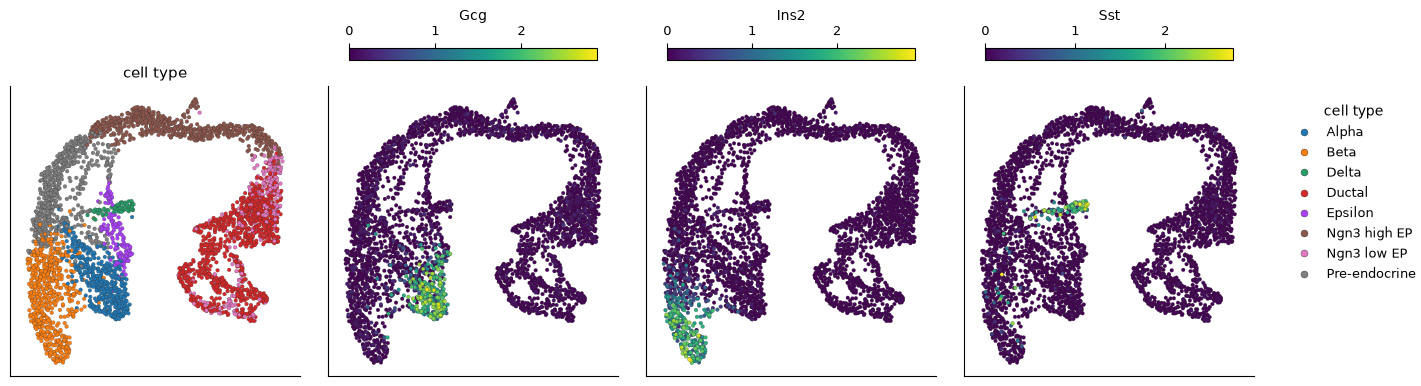

In [2]:
ds.plots.embedding(
    layout=layout,
    color_by=[cell_types, "Gcg", "Ins2", "Sst"],
    normalization=splt.NormalizationSpec(transform="log1p"),
    sort_values=True,
);

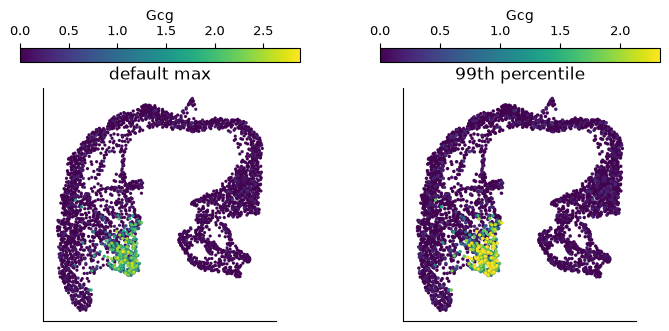

In [3]:
figure, axes = plt.subplots(1, 2, figsize=(7.2, 3.2), layout="constrained")
ds.plots.embedding(
    layout=layout,
    color_by="Gcg",
    normalization=splt.NormalizationSpec(transform="log1p"),
    sort_values=True,
    target=axes[0],
    show_titles=False,
    show=False,
)
ds.plots.embedding(
    layout=layout,
    color_by="Gcg",
    normalization=splt.NormalizationSpec(transform="log1p"),
    color_scale=splt.ColorScale(cmap="viridis", quantiles=(0.0, 0.99)),
    sort_values=True,
    target=axes[1],
    show_titles=False,
    show=False,
)
axes[0].set_title("default max")
axes[1].set_title("99th percentile")
figure

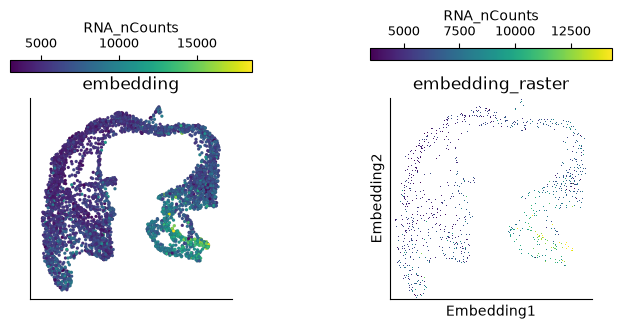

In [4]:
figure, axes = plt.subplots(1, 2, figsize=(7.2, 3.2), layout="constrained")
ds.plots.embedding(
    layout=layout,
    color_by="RNA_nCounts",
    target=axes[0],
    show_titles=False,
    show=False,
)
ds.plots.embedding_raster(
    layout=layout,
    color_by="RNA_nCounts",
    target=axes[1],
    show=False,
)
axes[0].set_title("embedding")
axes[1].set_title("embedding_raster")
figure

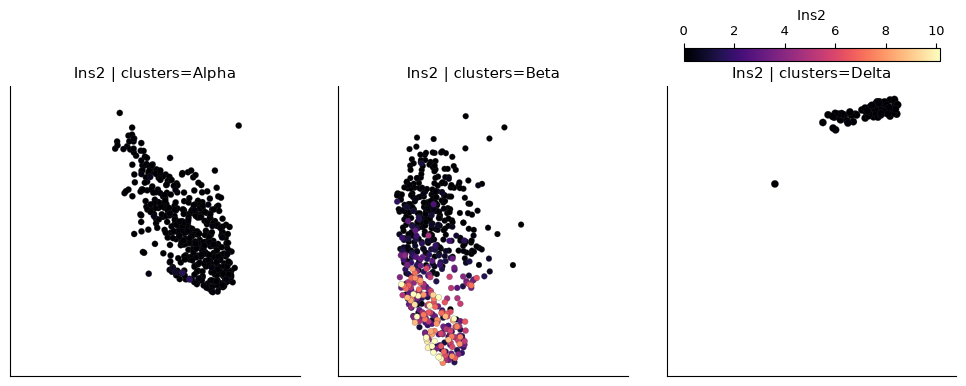

In [5]:
shared_expression_scale = splt.ColorScale(
    cmap="magma",
    quantiles=(0.0, 0.99),
)
ds.plots.embedding(
    layout=layout,
    color_by="Ins2",
    facet_by=cell_types.key,
    groups=["Alpha", "Beta", "Delta"],
    color_scale=shared_expression_scale,
    sort_values=True,
    n_columns=3,
);

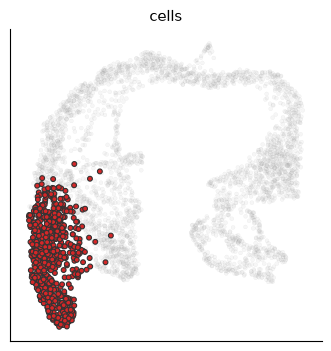

In [6]:
ds.plots.embedding(
    layout=layout,
    color_by=None,
    default_color="#bdbdbd",
    point_alpha=0.4,
    highlight=splt.Highlight(
        by=cell_types.key,
        groups=("Beta",),
    ),
);

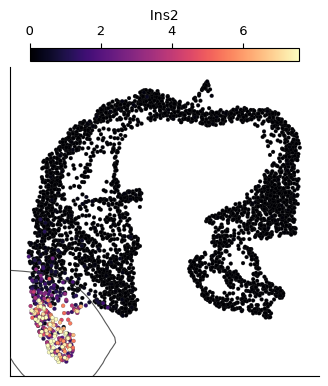

In [7]:
ds.plots.embedding(
    layout=layout,
    color_by="Ins2",
    color_scale=shared_expression_scale,
    sort_values=True,
    density_overlay=splt.DensityOverlay(
        statistic="mean",
        pixels=60,
        sigma=4.2,
        min_support=0.35,
        levels=(0.9,),
        max_hotspots=1,
    ),
);

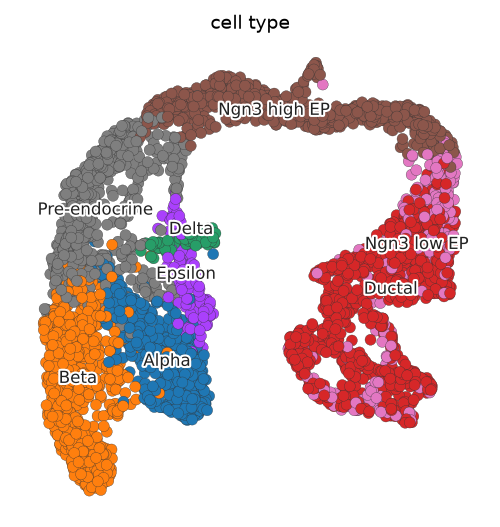

In [8]:
ds.plots.embedding(
    layout=layout,
    color_by=cell_types,
    legend_loc="on_data",
    frame="none",
    theme="paper",
    point_size=28,
);

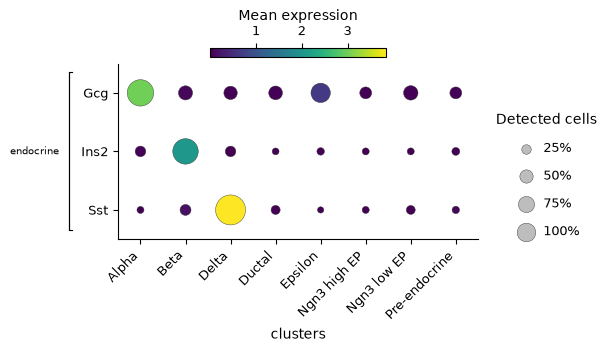

In [9]:
row = np.arange(ds.cells.N)
ds.cells.insert(
    "demo_sample",
    np.char.add("s", (row % 8).astype(str)),
    overwrite=True,
)
ds.cells.insert(
    "demo_subject",
    np.char.add("d", (row % 4).astype(str)),
    overwrite=True,
)
ds.cells.insert(
    "demo_condition",
    np.where(row % 8 < 4, "before", "after"),
    overwrite=True,
)

ds.plots.dotplot(
    features={"endocrine": ["Gcg", "Ins2", "Sst"]},
    group_by="clusters",
    sample_by="demo_sample",
);

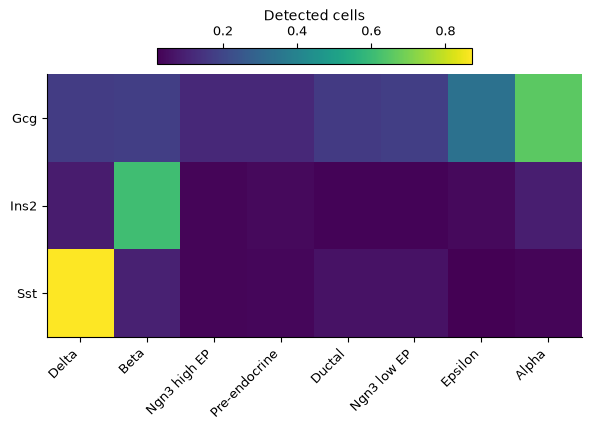

In [10]:
ds.plots.matrixplot(
    features=["Gcg", "Ins2", "Sst"],
    group_by="clusters",
    value="fraction",
    cluster_groups=True,
);

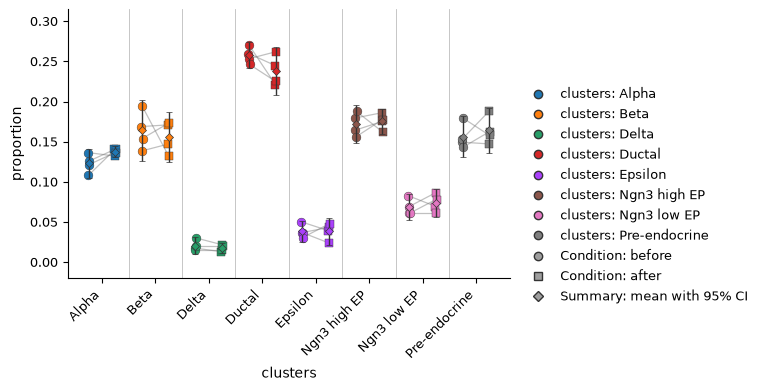

In [11]:
ds.plots.composition(
    category_by="clusters",
    study_design=splt.StudyDesign(
        sample_by="demo_sample",
        subject_by="demo_subject",
        condition_by="demo_condition",
    ),
    kind="per_sample",
);

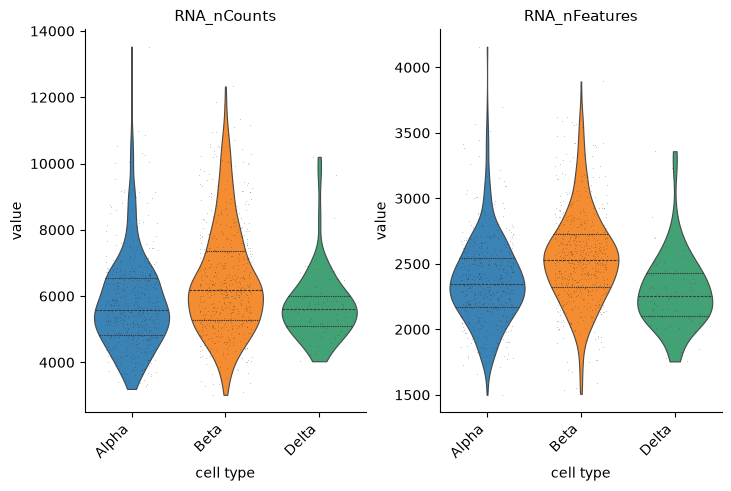

In [12]:
ds.plots.distribution(
    keys=["RNA_nCounts", "RNA_nFeatures"],
    grouping=cell_types,
    groups=["Alpha", "Beta", "Delta"],
    kind="violin",
    max_points=2000,
);

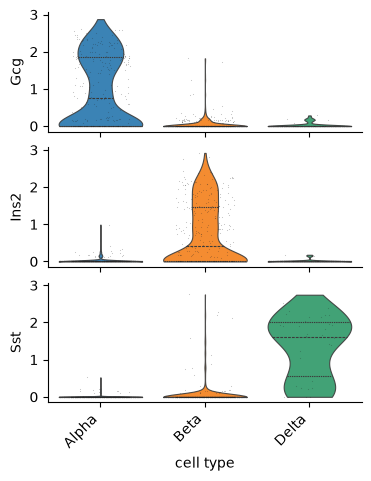

In [13]:
ds.plots.distribution(
    keys=["Gcg", "Ins2", "Sst"],
    grouping=cell_types,
    groups=["Alpha", "Beta", "Delta"],
    normalization=splt.NormalizationSpec(transform="log1p"),
    kind="stacked_violin",
    share_y=True,
    max_points=600,
);

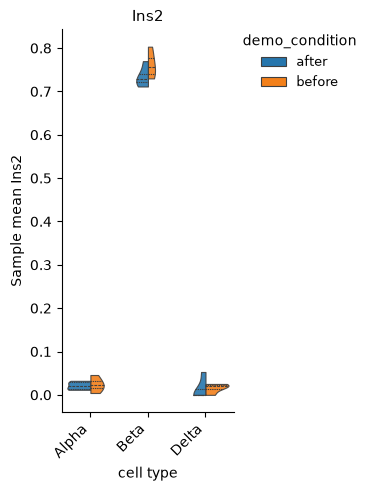

In [14]:
ds.plots.distribution(
    keys="Ins2",
    grouping=cell_types,
    groups=["Alpha", "Beta", "Delta"],
    sample_by="demo_sample",
    split_by="demo_condition",
    normalization=splt.NormalizationSpec(transform="log1p"),
    kind="violin",
    max_points=0,
);

In [15]:
output_directory = TemporaryDirectory()
out = Path(output_directory.name) / "plotting_showcase_embedding.png"
result = ds.plots.embedding(
    layout=layout,
    color_by=cell_types,
    show=False,
)
result.save(
    out,
    dpi=200,
    exact_size=True,
    provenance_sidecar=True,
)
sidecar = out.with_suffix(out.suffix + ".json")
provenance = json.loads(sidecar.read_text())["provenance"]
result.close()
provenance

{'assay': 'RNA',
 'cell_key': None,
 'extras': {'assays': [],
  'cell_selection': {'artifact_id': '948132cd146d3da6ec65f2341c8e35b04dff0f188442254af79688027656114c',
   'kind': 'cell_selection',
   'scope': 'datastore',
   'type': 'artifact'},
  'clip_fraction': 0.0,
  'color_artifacts': [],
  'color_limits': {},
  'color_scale_scope': 'feature',
  'density_overlay': None,
  'facet_by': None,
  'groups': None,
  'highlight': None,
  'input_n_cells': 3696,
  'invalid_coordinate_cells': 0,
  'layout': {'artifact_id': 'f3ed7f774ae6a902960e5ca6a0958042a35144ba6e0e481755355b8f5acd544d',
   'assay': 'RNA',
   'kind': 'embedding',
   'scope': 'assay',
   'type': 'artifact'},
  'n_colors': 1,
  'n_facets': 1,
  'normalization': {'source': 'assay', 'transform': 'none'},
  'omitted_labels': {},
  'omitted_legend_entries': {},
  'panel_keys': ['cell type'],
  'point_edgewidth_by_panel': {'cell type': 0.15},
  'point_size_by_panel': {'cell type': 7.723787032341993},
  'point_size_range': [1.0, 28.

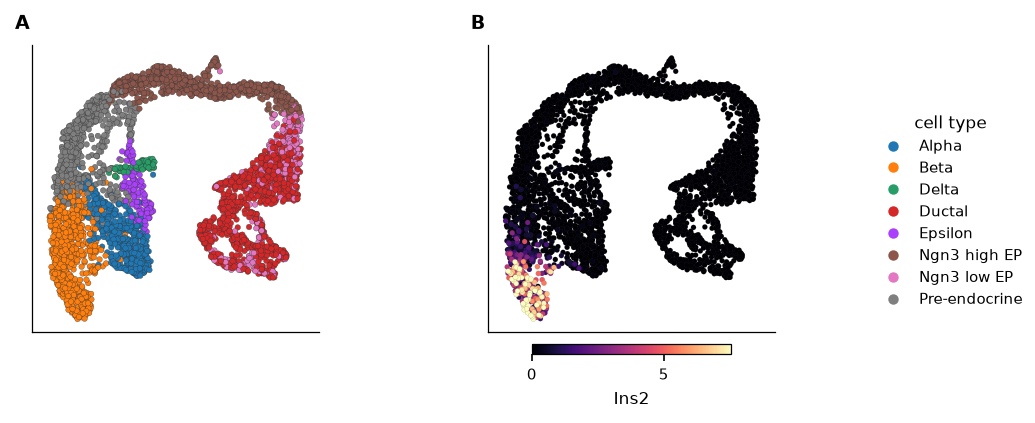

In [16]:
with splt.theme_context("paper"):
    figure, axes = plt.subplots(
        1,
        2,
        figsize=(7.2, 3.2),
        layout="constrained",
    )
    children = {
        "annotation": ds.plots.embedding(
            layout=layout,
            color_by=cell_types,
            legend_loc="on_data",
            show_legend=False,
            show_titles=False,
            target=axes[0],
            theme="paper",
            show=False,
        ),
        "expression": ds.plots.embedding(
            layout=layout,
            color_by="Ins2",
            color_scale=shared_expression_scale,
            sort_values=True,
            show_titles=False,
            target=axes[1],
            theme="paper",
            show=False,
        ),
    }
    composite = splt.compose_results(
        figure,
        children,
        panel_labels=False,
        shared_legends=True,
    )
    splt.label_panels(axes, labels=("A", "B"))
figure

In [17]:
composite_out = Path(output_directory.name) / "plotting_composite.svg"
composite.save(
    composite_out,
    provenance_sidecar=True,
)
plt.close(figure)